Average after normalization for list 0: 0.017654816309611004
Average after normalization for list 1: 0.04266780898684547
Average after normalization for list 2: 0.020310526802426294
0_md1/output/step4.0_minimization_amide.gro 
Average after normalization for 0_md1/output/step4.0_minimization_amide.gro: 0.017654816309611004
1_md1/output/step4.0_minimization_gna.gro 
Average after normalization for 1_md1/output/step4.0_minimization_gna.gro: 0.04266780898684547
2_md1/output/step4.0_minimization_unmod.gro 
Average after normalization for 2_md1/output/step4.0_minimization_unmod.gro: 0.020310526802426294


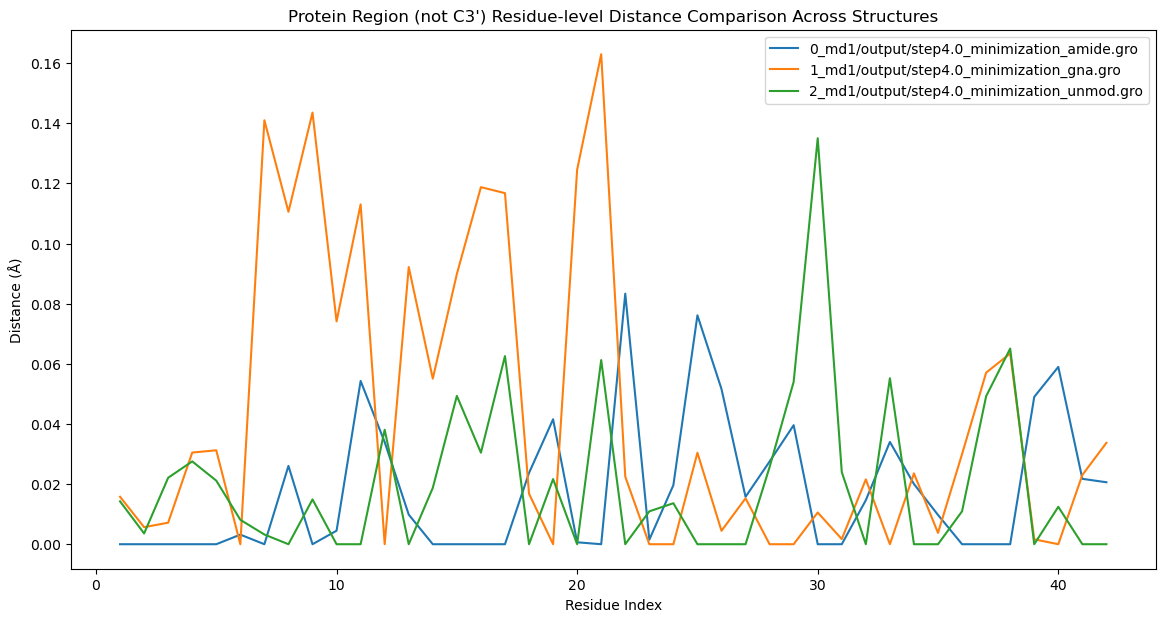

In [1]:
## GRAPHS RNA STRAND DATA 10-13-24
from pymol import cmd
import matplotlib.pyplot as plt
import os

cmd.reinitialize()
files = [

    ('../output_cifs/ENSG00000051382.cif', 'md1/output/step4.0_minimization_amide.gro'),
    ('../output_cifs/ENSG00000051382.cif', 'md1/output/step4.0_minimization_gna.gro'),
    ('../output_cifs/ENSG00000051382.cif', 'md1/output/step4.0_minimization_unmod.gro'), #unmod

]
combined_index_A = list(range(1, 43))
combined_distances_A = {}
index = 0 
for ref_file, comp_file in files:
    cmd.reinitialize()
    
    cmd.load(ref_file, 'ref')
    cmd.load(comp_file, 'comp')

    if cmd.count_atoms('ref') == 0 or cmd.count_atoms('comp') == 0:
        print(f"Error: One of the structures failed to load: {ref_file} or {comp_file}")
        continue

    cmd.remove('solvent')
    cmd.remove('ref and resn CL')
    cmd.remove('ref and resn NA+')
    cmd.remove('ref and hydrogen')
    cmd.remove('comp and hydrogen')

    alignment_rms = cmd.align('comp', 'ref')
    cmd.select("only_C3_ref", "ref and byres (name C3' or name C3G)")
    cmd.select("only_C3_comp", "comp and byres (name C3' or name C3G)")
    distances_A = []

    distances_chain_a = []
    distances_chain_b = []
    
    for resi in range(1, 22):
        cmd.select("first_rna_base_ref", f"byres (first (only_C3_ref and resi {resi}))")
        cmd.select("first_rna_base_comp", f"byres (first (only_C3_comp and resi {resi}))")
        dist_a = cmd.distance(f"dist_chain_a_resi_{resi}", "first_rna_base_ref", "first_rna_base_comp")
        distances_chain_a.append(dist_a)
    
        cmd.select("first_rna_base_ref_b", f"(only_C3_ref and resi {resi} and not first_rna_base_ref)")
        cmd.select("first_rna_base_comp_b", f"(only_C3_comp and resi {resi} and not first_rna_base_comp)")
        dist_b = cmd.distance(f"dist_chain_b_resi_{resi}", "first_rna_base_ref_b", "first_rna_base_comp_b")
        distances_chain_b.append(dist_b)

    comp_name = f"{index}_{comp_file}"
    combined_distances_A[comp_name] = distances_chain_a + distances_chain_b

    index += 1  



###################################################### normalize to the lowest change in any residue
for pair_key in combined_distances_A:
    distance_lists = list(combined_distances_A.values())
    if not distance_lists:
        continue
    num_indices = len(distance_lists[0])
    for i in range(num_indices):
        min_value = min(dist[i] for dist in distance_lists)
        for dist in distance_lists:
            dist[i] -= min_value
        #######
for idx, dist in enumerate(distance_lists):
    avg = sum(dist) / len(dist) if dist else 0
    print(f"Average after normalization for list {idx}: {avg}")
##########
for pair_key, distance_list in combined_distances_A.items():
    if not distance_list:
        continue
    avg = sum(distance_list) / len(distance_list) if distance_list else 0
    print(f"{pair_key} ")
    print(f"Average after normalization for {pair_key}: {avg}")
##########################################################
plt.figure(figsize=(14, 7))
for comp_name, distances in combined_distances_A.items():
    plt.plot(combined_index_A, distances, label=f'{comp_name}')
    # if comp_name.startswith("2_") or comp_name.startswith("3_"):
    #     plt.plot(combined_index_A, distances, label=f'{comp_name}')

plt.xlabel('Residue Index')
plt.ylabel('Distance (Å)')
plt.title("Protein Region (not C3') Residue-level Distance Comparison Across Structures")
plt.legend()
plt.show()
